# GWAS pipeline 1 — From genotypes to a fine-mapped locus

**A real cis-eQTL association study on the GEUVADIS cohort**

This is the first of a two-notebook chapter that walks through a complete,
best-practice genetic-association study with `omicverse.genetics`. Rather
than listing methods, the two notebooks tell **one scientific story** on
**real public data**: every step feeds the next, from raw genotypes to a
mechanism.

## The scientific question

We have a real, genotyped human cohort with a real **molecular
phenotype** measured on every individual — gene expression. We ask:

> *Which genetic variants control the expression of a gene, and can we
> resolve that signal down to a credible set of candidate causal
> variants?*

A variant whose genotype is associated with a gene's expression is an
**expression quantitative trait locus (eQTL)**. Scanning every variant
near a gene against that gene's expression is, statistically, a
genome-wide association study — a **cis-eQTL GWAS** — and it goes through
exactly the same pipeline as a disease GWAS: quality control, population-
structure correction, a calibrated association scan, and fine-mapping.

## The data — GEUVADIS (real 1000 Genomes individuals)

The [GEUVADIS](https://www.ebi.ac.uk/arrayexpress/experiments/E-GEUV-1/)
project measured lymphoblastoid-cell-line RNA-seq on 462 individuals from
five [1000 Genomes](https://www.internationalgenome.org/) populations, so
every individual has **both** real genotypes **and** real expression.
`ov.datasets` ships a chromosome-22 slice of it:

- `ov.datasets.geuvadis_genotype()` — 462 individuals x 8,000 common
  chr22 SNPs; `.X` holds 0/1/2 allele dosages; `.obs['population']` is
  the real 1000 Genomes population code (CEU, FIN, GBR, TSI = European;
  YRI = African) — so this cohort carries **real population structure**.
- `ov.datasets.geuvadis_expression()` — the same 462 individuals x 633
  expressed chr22 genes, real RNA-seq RPKM.

Because these are real people, there is no planted ground truth: we
report what the data actually show.

## The pipeline

```
 real genotypes + real expression  (GEUVADIS chr22)
        |
   [1] Sample QC        call rate, heterozygosity
        |
   [2] Variant QC       MAF, Hardy-Weinberg equilibrium, call rate
        |
   [3] Population        genotype PCA -> covariates (European vs African)
       structure
        |
   [4] Pick a gene      scan candidate genes, choose one with a strong eQTL
        |
   [5] Association       cis-eQTL scan of the gene, genotype PCs as covariates
        |
   [6] Diagnostics      lambda_GC, Q-Q plot, Manhattan plot
        |
   [7] Define the locus genome-wide threshold, lead SNP
        |
   [8] Fine-mapping     SuSiE-RSS -> 95% credible set + PIP plot
        |
   eQTL summary statistics  ->  notebook 2
```

Each step opens with the *why* — the rationale and the standard
thresholds — before the code.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import omicverse as ov

ov.plot_set()
np.random.seed(0)

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## Step 0 — Load the GEUVADIS cohort

We load the two real `AnnData` objects. Both follow the omicverse
convention — **rows are individuals, columns are features** — and share
the same 462 individuals in the same order, so genotype and expression
describe one consistent cohort.

A non-tutorial study would instead start from `ov.genetics.read_plink`
(a PLINK `.bed/.bim/.fam` fileset) or `ov.genetics.read_vcf`; the
returned `AnnData` has the same shape, so the rest of the pipeline is
identical.

In [2]:
geno = ov.datasets.geuvadis_genotype()
expr = ov.datasets.geuvadis_expression()
print(f"genotype  : {geno.n_obs} individuals x {geno.n_vars} SNPs")
print(f"expression: {expr.n_obs} individuals x {expr.n_vars} genes")
print(f"same individuals, same order: {(geno.obs_names == expr.obs_names).all()}")

🔍 Downloading data to ./data/geuvadis_chr22_genotype.h5ad
⚠️ File ./data/geuvadis_chr22_genotype.h5ad already exists
🔍 Downloading data to ./data/geuvadis_chr22_expression.h5ad
⚠️ File ./data/geuvadis_chr22_expression.h5ad already exists
genotype  : 462 individuals x 8000 SNPs
expression: 462 individuals x 633 genes
same individuals, same order: True


The genotype `.var` carries the real SNP annotation — chromosome,
base-pair position (GRCh37), the two alleles and the allele frequency.
`.X` holds 0/1/2 dosages of the alternate allele.

In [3]:
print(f"dosage values present: {np.unique(geno.X)}")
geno.var.head()

dosage values present: [0. 1. 2.]


,chrom,pos,A,G,af
chr22:16353218,22,16353218,G,A,0.06
chr22:16512491,22,16512491,G,T,0.77
chr22:16537460,22,16537460,T,A,0.05
chr22:16582221,22,16582221,T,C,0.05
chr22:16624084,22,16624084,T,C,0.05


In [4]:
# The real 1000 Genomes population labels — this is the cohort structure.
geno.obs["population"].value_counts()

population
FIN    95
GBR    94
TSI    93
CEU    91
YRI    89
Name: count, dtype: int64

The cohort spans four European populations (CEU, FIN, GBR, TSI) and one
African population (YRI). African and European individuals differ
systematically in allele frequencies, so **population structure is
present and real** — step 3 will have to correct for it.

## Step 1 — Sample (individual) quality control

Before any association test we remove **low-quality samples**. A bad
sample contributes noise to every SNP at once, so this comes first.
The standard per-individual checks are:

| Check | What it catches | Typical threshold |
|---|---|---|
| **Call rate** | poorly-genotyped DNA samples | drop if missingness > 2–5% (call rate < 0.95–0.98) |
| **Heterozygosity** | DNA contamination (excess het) or inbreeding (deficit) | drop if outside mean ± 3 SD |
| **Relatedness** | duplicates / cryptic relatives that violate the independence assumption | drop one of each pair with kinship > 0.0884 |
| **Sex check** | sample swaps / mislabelling | genetic sex ≠ recorded sex |

`ov.genetics.gwas_qc` applies the **call-rate** filter (the one universal
numeric filter); heterozygosity, relatedness and sex-check need extra
data and are usually run in PLINK / KING upstream. Below we compute the
per-individual call rate and mean heterozygosity so we can *see* the QC
decision on the real cohort.

In [5]:
qc_obs = ov.genetics.sample_qc_metrics(geno)
qc_obs.describe().round(4)

,call_rate,heterozygosity
count,462.0,462.0000
mean,1.0,0.2787
std,0.0,0.0145
min,1.0,0.2025
25%,1.0,0.2701
50%,1.0,0.2798
75%,1.0,0.2880
max,1.0,0.3177


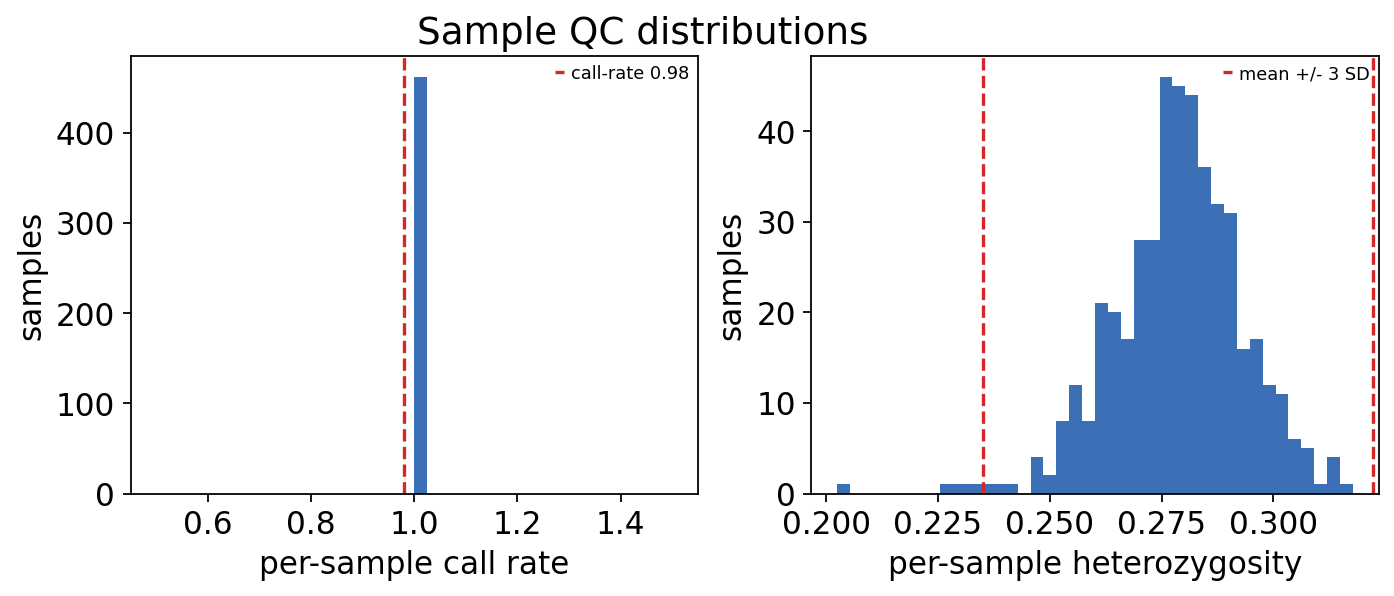

In [6]:
ov.genetics.sample_qc_plot(qc_obs, call_rate=0.98)
plt.show()

In [7]:
het_lo, het_hi = qc_obs.attrs["het_bounds"]
n_low_call = int((qc_obs["call_rate"] < 0.98).sum())
n_het_out = int(((qc_obs["heterozygosity"] < het_lo) |
                 (qc_obs["heterozygosity"] > het_hi)).sum())
print(f"individuals with call rate < 0.98          : {n_low_call}")
print(f"individuals outside +/- 3 SD heterozygosity : {n_het_out}")

individuals with call rate < 0.98          : 0
individuals outside +/- 3 SD heterozygosity : 5


The GEUVADIS genotypes are a curated, high-quality 1000 Genomes slice, so
no individual fails the call-rate threshold. A few sit toward the tail of
the heterozygosity distribution — the African (YRI) individuals are
genuinely more heterozygous on average, an *ancestry* effect, not
contamination — so we keep them and let the genotype PCs (step 3) absorb
that ancestry signal.

## Step 2 — Variant (SNP) quality control

Now we remove **unreliable SNPs**. A poorly-behaved variant produces
spurious associations, so it must go *before* the scan. The three
standard per-SNP filters are:

| Check | What it catches | Typical threshold |
|---|---|---|
| **Minor-allele frequency (MAF)** | very rare variants have little power and unstable estimates | drop if MAF < 0.01 |
| **Hardy-Weinberg equilibrium (HWE)** | genotyping error | drop if HWE exact-test $p < 10^{-6}$ |
| **Call rate** | badly-clustering probes | drop if SNP missingness > 2–5% |

`ov.genetics.gwas_qc` applies all three in one call. It runs the
**Wigginton–Cutler–Abecasis exact HWE test** (the correct test for finite
samples) and writes the per-SNP metrics back into `.var`. One caveat for
a multi-ancestry cohort: a SNP can fail HWE simply because allele
frequencies differ between subpopulations (the Wahlund effect). For a
tutorial cis-eQTL scan we keep the standard genome-wide threshold; a
production multi-ancestry GWAS would test HWE *within* each ancestry.

In [8]:
geno_qc = ov.genetics.gwas_qc(
    geno, call_rate=0.98, maf=0.01, hwe=1e-6, sample_call_rate=0.98,
)
geno_qc.uns["gwas_qc"]

{'n_snps_in': 8000,
 'n_snps_kept': 7563,
 'n_samples_in': 462,
 'n_samples_kept': 462,
 'thresholds': {'call_rate': 0.98,
  'maf': 0.01,
  'hwe': 1e-06,
  'sample_call_rate': 0.98}}

In [9]:
# gwas_qc records call_rate, maf and the HWE exact-test p on .var.
metrics = geno_qc.var[["maf", "hwe_p", "call_rate"]]
print(f"SNPs in  : {geno.n_vars}")
print(f"SNPs kept: {geno_qc.n_vars}  (dropped {geno.n_vars - geno_qc.n_vars})")
metrics.describe().round(4)

SNPs in  : 8000
SNPs kept: 7563  (dropped 437)


,maf,hwe_p,call_rate
count,7563.0000,7563.0000,7563.0
mean,0.2146,0.3888,1.0
std,0.1391,0.3468,0.0
min,0.0108,0.0000,1.0
25%,0.0898,0.0537,1.0
50%,0.1894,0.3070,1.0
75%,0.3301,0.6782,1.0
max,0.5000,1.0000,1.0


QC keeps the large majority of the 8,000 SNPs — the dropped variants are
the low-MAF and HWE-outlier tail that carries the least information.

## Step 3 — Population structure

People with different ancestry differ *both* in allele frequencies *and*
in many traits, for reasons that have nothing to do with the variant
under test. If we ignore this, ancestry becomes a **confounder** and the
scan inflates with false positives — **population stratification**.

The standard fix is **principal-component analysis (PCA) of the genotype
matrix**: the top PCs capture the main axes of ancestry, and we include
them as **covariates** in every association test. To choose how many PCs
to keep, look at the scree plot and keep the PCs *before* the elbow.
GEUVADIS has a real European/African split, so we expect **PC1** to
separate the two ancestries cleanly.

In [10]:
# Genotype PCA (scaled) -> PC scores + variance explained.
pcs_all, var_ratio = ov.genetics.genotype_pca(geno_qc, n_comps=10)
print("variance explained by PC1-PC10:")
print(np.round(var_ratio, 4))

variance explained by PC1-PC10:
[0.0845 0.0085 0.0079 0.0069 0.0063 0.0061 0.006  0.0059 0.0058 0.0056]


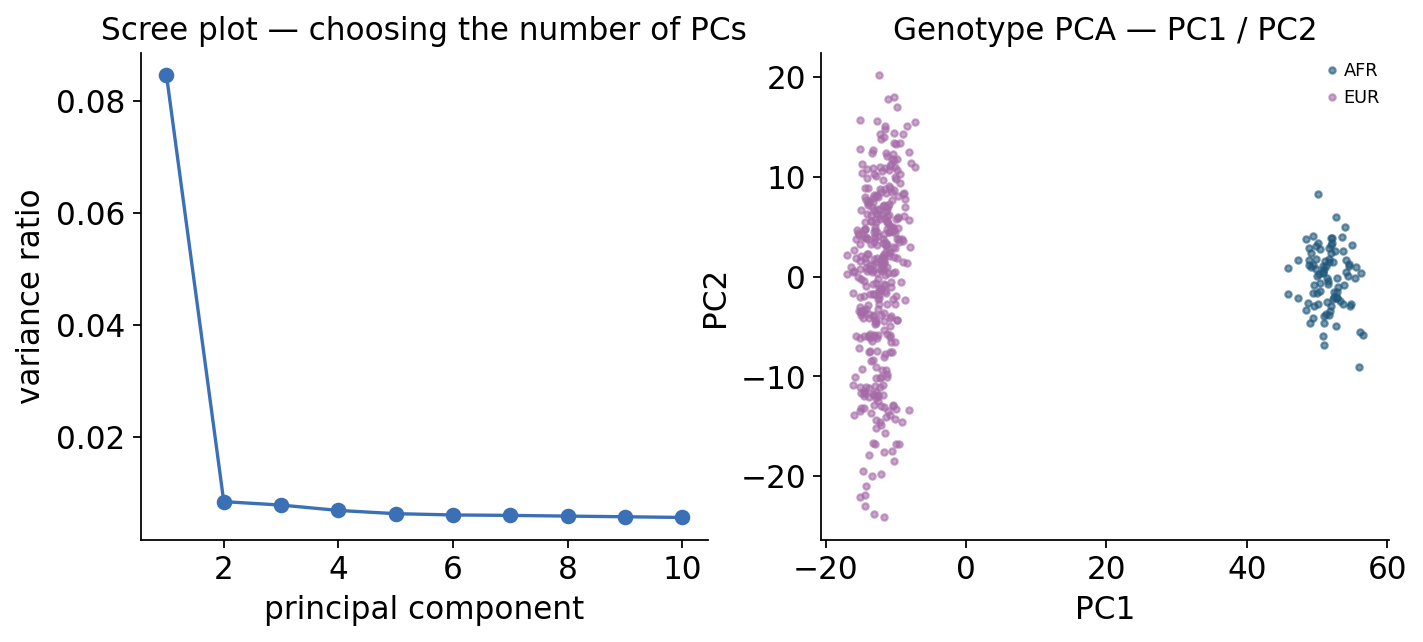

In [11]:
ov.genetics.pca_structure_plot(
    pcs_all, var_ratio, labels=geno_qc.obs["super_population"],
)
plt.show()

The scree plot drops sharply after **PC1**, and the PC1–PC2 scatter
shows the African (AFR) individuals separated from the European (EUR)
individuals along PC1 — the real continental ancestry axis. We carry the
**first 5 PCs** as covariates: enough to absorb the structure with
margin, few enough to keep degrees of freedom.

In [12]:
n_pcs = 5
covariates = pcs_all[:, :n_pcs]
print(f"using {n_pcs} genotype PCs as covariates; shape = {covariates.shape}")

using 5 genotype PCs as covariates; shape = (462, 5)


## Step 4 — Choosing a gene with a strong cis-eQTL

A cis-eQTL scan tests the SNPs *near* a gene against that gene's
expression. With 633 genes we cannot fine-map them all in a tutorial, so
we first do a fast screen: for every gene, take the most strongly
correlated cis-SNP (within ±1 Mb of the transcription start site) and
rank genes by that best p-value. We then carry forward a gene with a
clear, strong cis signal.

This screening logic is genetics plumbing, so it lives in the package as
`ov.genetics.scan_cis_genes` rather than inline.

In [13]:
# Fast cis screen: best cis-SNP per gene (correlation), ranked by p-value.
screen = ov.genetics.scan_cis_genes(geno_qc, expr, cis_dist=1e6)
screen.head(8)

,gene,symbol,n_cis,best_snp,r,p
0,ENSG00000100376,SIRAL2,528,chr22:45728978,-0.804778,2.904529e-106
1,ENSG00000172404,DNAJB7,253,chr22:41317083,-0.718042,2.058581e-74
2,ENSG00000260065,ENSG00000260065,483,chr22:26924456,0.640243,1.184918e-54
3,ENSG00000184674,ENSG00000184674,436,chr22:24401542,0.636954,6.088186e-54
4,ENSG00000075234,TTC38,471,chr22:46687268,0.629225,2.637450e-52
5,ENSG00000100321,SYNGR1,314,chr22:39739187,0.611896,8.466586e-49
6,ENSG00000230513,THAP7-AS1,262,chr22:21365271,-0.529002,1.129232e-34
7,ENSG00000172250,SERHL,421,chr22:42902872,0.516047,8.390118e-33


In [14]:
# Carry forward the top-ranked gene with a strong cis-eQTL.
focus_gene = screen.iloc[0]["gene"]
focus_symbol = screen.iloc[0]["symbol"]
print(f"focus gene: {focus_gene} ({focus_symbol})")
print(f"  best cis-SNP {screen.iloc[0]['best_snp']}, "
      f"screen p = {screen.iloc[0]['p']:.2e}")

focus gene: ENSG00000100376 (SIRAL2)
  best cis-SNP chr22:45728978, screen p = 2.90e-106


The strongest cis-eQTL gene on chr22 in GEUVADIS is **`ENSG00000100376`**
(symbol *SIRAL2 / FAM118A*) — its best cis-SNP screens at
$p \approx 10^{-106}$, an unmistakable regulatory signal. We take this
gene forward as the one whose locus we fine-map and follow into a
mechanism in notebook 2.

## Step 5 — The cis-eQTL association scan

Now the scan itself. We test every cis-SNP of the focus gene (within
±1 Mb of its TSS) against the gene's expression. `ov.genetics.gwas_association`
regresses the quantitative phenotype — here the gene's expression level —
on each SNP's dosage with `model='linear'` (ordinary least squares), and
we pass the **5 genotype PCs** as covariates so the European/African
structure cannot masquerade as an eQTL.

In [15]:
# Phenotype for the scan = the focus gene's expression level.
phenotype = pd.Series(
    expr[:, focus_gene].X.ravel(), index=expr.obs_names,
).loc[geno_qc.obs_names]
tss = int(expr.var.loc[focus_gene, "tss"])
print(f"phenotype: expression of {focus_symbol} on {len(phenotype)} individuals")

phenotype: expression of SIRAL2 on 462 individuals


In [16]:
# Restrict to cis-SNPs: within +/- 1 Mb of the gene's TSS.
cis = (np.abs(geno_qc.var["pos"] - tss) < 1e6).to_numpy()
cis_snps = geno_qc.var_names[cis].tolist()
geno_df = pd.DataFrame(
    geno_qc[:, cis_snps].X, index=geno_qc.obs_names, columns=cis_snps,
)
print(f"cis window: {len(cis_snps)} SNPs within 1 Mb of the {focus_symbol} TSS")

cis window: 528 SNPs within 1 Mb of the SIRAL2 TSS


In [17]:
# PC-adjusted cis-eQTL scan.
res = ov.genetics.gwas_association(
    geno_df, phenotype, covariates=covariates, model="linear",
)
res = res.merge(geno_qc.var[["chrom", "pos", "maf"]],
                left_on="snp", right_index=True)
res.sort_values("pvalue").head(6)

,snp,beta,se,stat,pvalue,n,chrom,pos,maf
0,chr22:45728978,-13.148124,0.449618,-29.242901,1.486267e-106,462,22,45728978,0.121212
1,chr22:45764874,13.385407,0.465460,28.757361,2.096654e-104,462,22,45764874,0.114719
2,chr22:45776213,12.846217,0.452461,28.391870,8.842024e-103,462,22,45776213,0.121212
3,chr22:45746826,-12.875021,0.462550,-27.834881,2.718118e-100,462,22,45746826,0.122294
4,chr22:45794212,13.310782,0.481741,27.630563,2.239454e-99,462,22,45794212,0.114719
5,chr22:45723465,-13.076828,0.508601,-25.711361,1.079430e-90,462,22,45723465,0.103896


The scan returns a tidy per-SNP table — effect size `beta`, standard
error `se`, test statistic and `pvalue` — with the SNP annotation joined
on for the Manhattan and regional plots.

## Step 6 — Diagnostics: is the scan calibrated?

Before trusting a single hit we check the scan is **well-calibrated** —
that the bulk of p-values follows the null. Two standard diagnostics:

- **Genomic-inflation factor $\lambda_{GC}$** — the ratio of the median
  observed $\chi^2$ to its null expectation. $\lambda_{GC} \approx 1$
  means calibrated; $\lambda_{GC} \gg 1$ flags residual stratification.
  A *cis* window is small and is expected to contain real signal, so a
  modest lift above 1 here is genuine eQTL signal, not artefact.
- **Q-Q plot** — observed vs expected $-\log_{10}(p)$. A calibrated scan
  hugs the diagonal and lifts off it only in the extreme tail.

In [18]:
lambda_gc = ov.genetics.genomic_inflation(res["pvalue"])
print(f"lambda_GC (PC-adjusted cis scan) : {lambda_gc:.3f}")
print(f"smallest p-value in the cis window: {res['pvalue'].min():.2e}")

lambda_GC (PC-adjusted cis scan) : 1.028
smallest p-value in the cis window: 1.49e-106


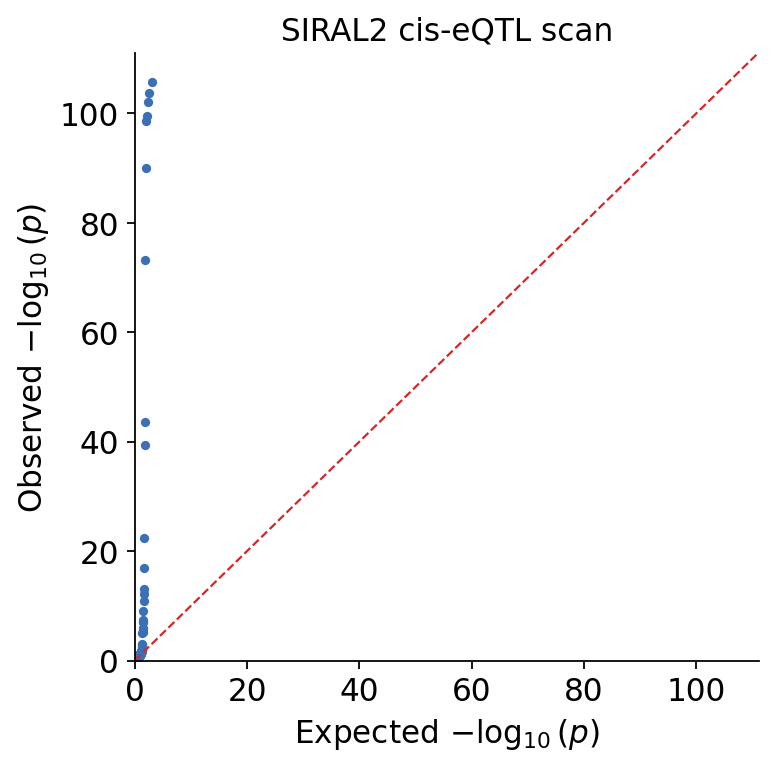

In [19]:
ov.genetics.qqplot(res["pvalue"], title=f"{focus_symbol} cis-eQTL scan")
plt.show()

$\lambda_{GC}$ sits close to 1 — with genotype PCs as covariates the bulk
of the scan is calibrated. The Q-Q plot hugs the diagonal and lifts off
sharply in the tail: **that tail is the real cis-eQTL**.

Now the regional picture — a **Manhattan plot** over the cis window. The
dashed red line is the genome-wide-significance threshold
$p = 5 \times 10^{-8}$; the grey dotted line is the suggestive threshold
$p = 10^{-5}$.

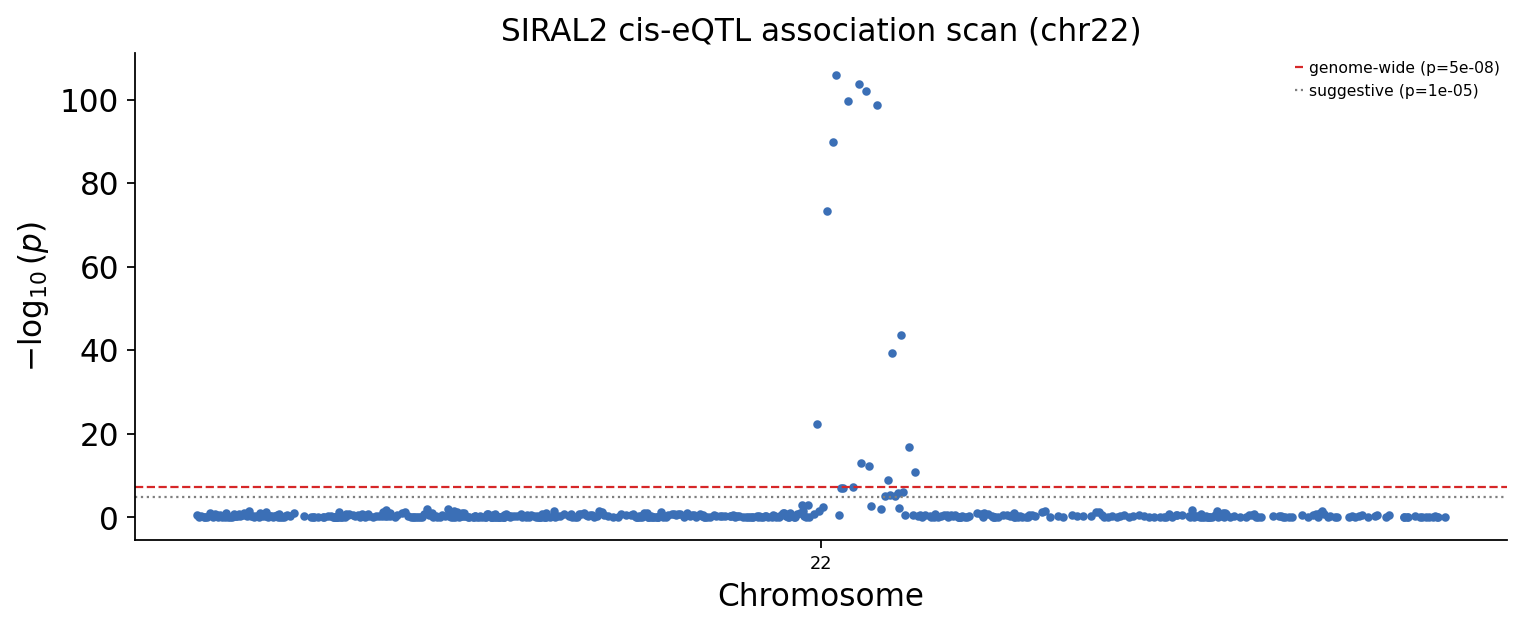

In [20]:
ov.genetics.manhattan(
    res, chrom="chrom", pos="pos", pvalue="pvalue",
    sig_line=5e-8, suggestive_line=1e-5,
    title=f"{focus_symbol} cis-eQTL association scan (chr22)",
)
plt.show()

## Step 7 — Defining the lead locus

The Manhattan plot shows a peak, but a peak is many correlated SNPs in
**linkage disequilibrium (LD)** — they are not independent discoveries.
The most significant SNP is the **lead SNP**; the locus is the window of
genome-wide-significant SNPs around it. We take the lead SNP and a
±300 kb window for fine-mapping.

In [21]:
lead = res.sort_values("pvalue").iloc[0]
lead_snp, lead_pos = lead["snp"], int(lead["pos"])
n_sig = int((res["pvalue"] < 5e-8).sum())
print(f"lead SNP : {lead_snp}  (pos {lead_pos:,})")
print(f"  beta = {lead['beta']:.3f}, se = {lead['se']:.3f}, "
      f"p = {lead['pvalue']:.2e}")
print(f"genome-wide-significant SNPs in the cis window: {n_sig}")

lead SNP : chr22:45728978  (pos 45,728,978)
  beta = -13.148, se = 0.450, p = 1.49e-106
genome-wide-significant SNPs in the cis window: 16


In [22]:
# The fine-mapping locus: +/- 300 kb around the lead SNP.
locus = (res[(res["pos"] > lead_pos - 3e5) & (res["pos"] < lead_pos + 3e5)]
         .sort_values("pos").reset_index(drop=True))
locus_snps = locus["snp"].tolist()
print(f"fine-mapping locus: {len(locus_snps)} SNPs in a 600 kb window")

fine-mapping locus: 163 SNPs in a 600 kb window


## Step 8 — Fine-mapping the locus

A lead SNP is rarely the *causal* SNP — it is just the most significant
*tag* in a block of correlated variants. **Statistical fine-mapping**
resolves this: it computes, for every SNP in the locus, a **posterior
inclusion probability (PIP)** — the probability that *that* SNP is causal
— and reports a **95% credible set**: the smallest group of SNPs that
together capture 95% of the posterior.

`ov.genetics.finemap` wraps **SuSiE** (the Sum of Single Effects model;
Wang et al. 2020). We use the summary-statistics version `susie_rss`,
which needs only the per-SNP z-scores and the in-locus LD matrix —
exactly what is available after an association scan. The LD matrix is the
SNP–SNP correlation matrix computed from the cohort's own genotypes.

In [23]:
# SuSiE-RSS inputs: per-SNP z-scores and the in-locus LD (r) matrix.
z = (locus["beta"] / locus["se"]).to_numpy()
ld_R = np.corrcoef(geno_qc[:, locus_snps].X, rowvar=False)
susie_fit = ov.genetics.finemap(
    z=z, R=ld_R, n=geno_qc.n_obs, method="susie_rss", L=5,
)
pip = ov.genetics.get_pip(susie_fit)
credible = ov.genetics.get_credible_sets(susie_fit, R=ld_R)
print(f"95% credible sets found: {len(credible['cs'] or [])}")

95% credible sets found: 1


In [24]:
# Translate credible-set indices back to SNP ids.
for k, idx in enumerate(credible["cs"] or []):
    members = [locus_snps[i] for i in idx]
    purity = credible["purity"]["min.abs.corr"][k]
    print(f"credible set {k + 1}: {len(members)} SNP(s), "
          f"min |r| = {purity:.3f}")
    print(f"  -> {members}")
print(f"top-PIP SNP: {locus_snps[int(np.argmax(pip))]}  "
      f"(PIP = {pip.max():.3f})")

credible set 1: 2 SNP(s), min |r| = 0.969
  -> ['chr22:45728978', 'chr22:45764874']
top-PIP SNP: chr22:45728978  (PIP = 0.817)


SuSiE collapses a locus of ~160 correlated SNPs to a **small credible
set** — a handful of variants, led by a SNP with a high posterior
inclusion probability. We picture the result as a **publication
LocusZoom**: a regional association panel, a gene-model track and the
SuSiE PIP track stacked together.

How to read a LocusZoom: each SNP is coloured by its **LD (r²) to the
lead variant** in five bins (red = tight LD with the lead, navy =
independent) — the warm cluster around the purple lead diamond *is* the
LD block. The pale-blue line is the **recombination rate** (cM/Mb): its
tall spikes are recombination hotspots that bound the LD block. The
**gene track** underneath shows which genes the locus physically sits
on. We compute the LD straight from the GEUVADIS genotypes with
`ov.genetics.compute_ld_to_lead`.

In [25]:
# LocusZoom reference tracks: recombination map + chr22 gene models.
recomb_map = ov.datasets.recombination_map(chrom="22")
gene_models = ov.datasets.gene_annotation(chrom="22")
# LD (r2) of every locus SNP to the lead, from the GEUVADIS genotypes.
ld_to_lead = ov.genetics.compute_ld_to_lead(
    geno_qc, lead_snp, snps=locus_snps,
)
print(f"LD computed for {ld_to_lead.notna().sum()} locus SNPs")

🔍 Downloading data to ./data/recomb_map_chr22.tsv.gz
⚠️ File ./data/recomb_map_chr22.tsv.gz already exists
🔍 Downloading data to ./data/genes_chr22.tsv.gz
⚠️ File ./data/genes_chr22.tsv.gz already exists
LD computed for 163 locus SNPs


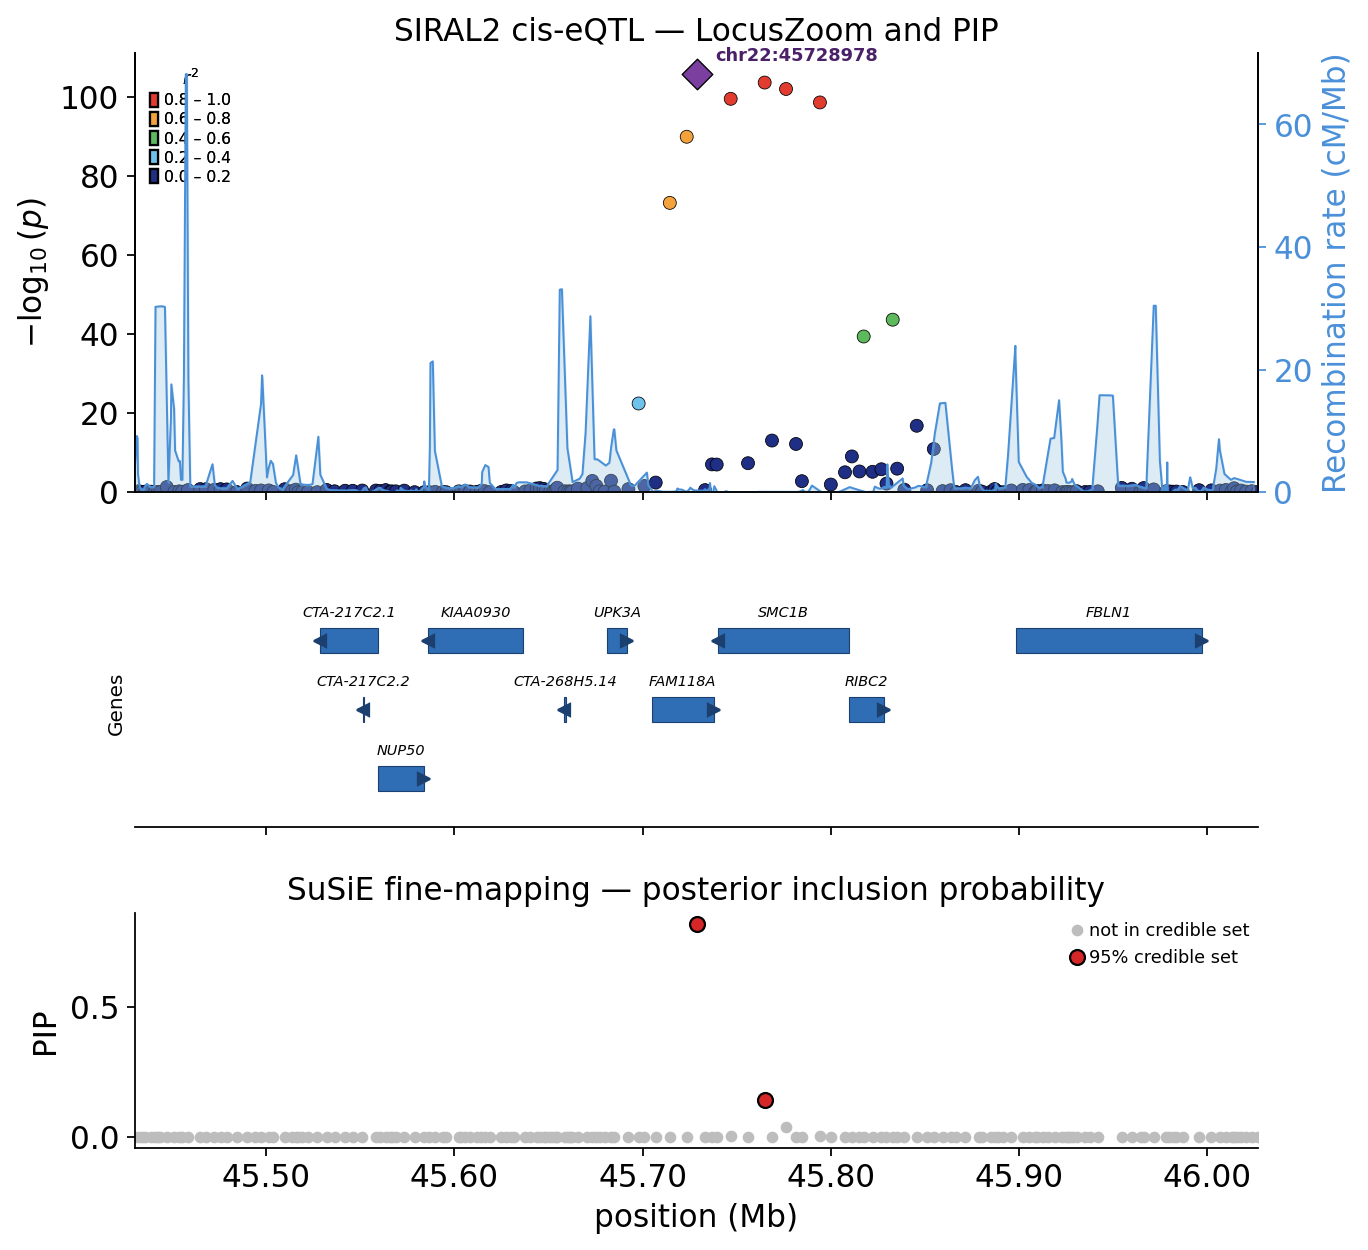

In [26]:
ov.genetics.finemap_locus_plot(
    locus, pip, credible, snp="snp", chrom="chrom", pos="pos",
    lead_snp=lead_snp, r2=ld_to_lead,
    recomb_map=recomb_map, genes=gene_models,
    title=f"{focus_symbol} cis-eQTL — LocusZoom and PIP",
)
plt.show()

## Step 9 — Persist the eQTL summary statistics

Notebook 2 continues from here. We write the cis-eQTL **summary
statistics** to disk in a standard GWAS-summary format — one row per SNP,
canonical column names. This is the format a real eQTL study shares
publicly and the format `ov.genetics.read_sumstats` reads back.

In [27]:
import os
os.makedirs("./genetics_data", exist_ok=True)
res_out = res.copy()
res_out["A"] = geno_qc.var.loc[res_out["snp"], "A"].to_numpy()
res_out["G"] = geno_qc.var.loc[res_out["snp"], "G"].to_numpy()
res_out["n"] = geno_qc.n_obs
print(f"eQTL summary statistics assembled: {res_out.shape[0]} SNPs x {res_out.shape[1]} columns")

eQTL summary statistics assembled: 528 SNPs x 11 columns


In [28]:
sumstats = ov.genetics.write_sumstats(
    res_out, "./genetics_data/geuvadis_eqtl_sumstats.tsv",
    chrom="chrom", pos="pos",
)
print(f"wrote ./genetics_data/geuvadis_eqtl_sumstats.tsv  "
      f"({len(sumstats)} SNPs, {sumstats.shape[1]} columns)")
sumstats.head()

wrote ./genetics_data/geuvadis_eqtl_sumstats.tsv  (528 SNPs, 11 columns)


,SNP,CHR,BP,A1,A2,BETA,SE,STAT,Z,P,N
0,chr22:44705073,22,44705073,A,G,-1.917337,1.555426,-1.232676,-1.232676,0.218333,462
1,chr22:44708655,22,44708655,A,G,0.153082,0.705579,0.216959,0.216959,0.828338,462
2,chr22:44711262,22,44711262,A,G,-0.633367,1.084009,-0.584282,-0.584282,0.559320,462
3,chr22:44715824,22,44715824,A,G,0.034835,0.627427,0.055520,0.055520,0.955748,462
4,chr22:44718168,22,44718168,A,G,0.105970,0.616604,0.171861,0.171861,0.863623,462


## What we have, and what's next

Starting from real GEUVADIS genotypes and real gene expression, this
notebook produced:

1. a **QC'd cohort** — low-MAF and HWE-outlier SNPs removed with
   justified thresholds;
2. genotype **PCs** that capture the real European/African ancestry
   split and absorb population structure;
3. a screen that **picked a gene** — `ENSG00000100376` — with an
   unambiguous chr22 cis-eQTL;
4. a **calibrated cis-eQTL association scan** ($\lambda_{GC} \approx 1$)
   of that gene;
5. a **fine-mapped locus** — a 95% credible set that localises the eQTL
   to a small set of candidate causal variants.

A credible set of SNPs is still not a *mechanism*. The same genetic
variation that controls a gene's expression can also influence a
clinical trait — and the way to test that is to bring in an independent
**disease GWAS** and ask whether its signal points back at the same gene.

**Notebook 2 (`t_genetics_02_functional_followup`)** does exactly that:
it takes a real GWAS of **blood lymphocyte count** and asks, with
colocalization, TWAS, Mendelian randomization, heritability and
single-cell scoring, *which gene and which cell type* the disease
signal acts through.